In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import random
import itertools

sys.path.append('../')

from src.piece_functions import helix,cast_and_surge,persistent_random_walk,straight_line,generate_random_trajectory
from src.io import save_dataframe

/home/hugo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def canonicalize_trajectory(coords, *, return_rotation=False, normalize_step=False, tol=1e-12):
    """
    Rotate `coords` (KxD) into a unique canonical frame.
    Works for 2D (D=2) and 3D (D=3).

    Parameters:
    - coords: Input trajectory (K, D)
    - return_rotation: If True, returns the rotation matrix V.
    - normalize_step: If True, resamples the trajectory so the distance 
      between every consecutive point is exactly 1.0. Returns the original
      'speeds' (distances) as an extra output.
    - tol: Numerical tolerance for sign disambiguation.
    """
    X = np.asarray(coords, dtype=float)
    speeds = None

    # --- Existing Logic: Rigid Alignment ---
    K, D = X.shape
    
    # 1. Centre at centroid
    C = X - X.mean(axis=0)
    
    # 2. PCA -> eigenvectors V
    _, _, Vt = np.linalg.svd(C, full_matrices=False)
    V = Vt.T

    Y = C @ V
    
    # 3. Sign disambiguation (loop over D dimensions)
    for j in range(D):
        m3 = (Y[:, j] ** 3).sum()
        if abs(m3) < tol:
            k = (j + 1) % D
            m3 = (Y[:, j]**2 * Y[:, k]).sum()
        if m3 < 0:
            V[:, j] *= -1
            Y[:, j] *= -1

    # 4. Make basis right-handed (det = +1)
    if np.linalg.det(V) < 0:
        V[:, -1] *= -1
        Y[:, -1] *= -1

    canon = Y
    
    # Step 6: Chiral disambiguation via lexicographic minimization
    mirrors = np.array(list(itertools.product([1, -1], repeat=D))) 
    
    # Einstein sum: (2^D, D) x (K, D) -> (2^D, K, D)
    # Note: I swapped the einsum logic slightly to match standard broadcasting 
    # but kept the user's intent: mirrors[i, j] * canon[k, j]
    mirrored = np.einsum('ij,kj->kij', canon, mirrors)

    flat = mirrored.reshape(len(mirrors), -1)
    best_index = np.lexsort(flat.T)[0]
    canon = mirrored[best_index]

    # --- New Logic: Step Normalization ---
    if normalize_step:
        # Calculate vector differences between points
        diffs = X[1:] - X[:-1]
        
        # Calculate L2 norm (distance/speed) for each segment
        # Handle division by zero for duplicate points by adding epsilon if needed, 
        # or rely on valid input.
        distances = np.linalg.norm(diffs, axis=1)
        
        # Normalize vectors to unit length
        # Avoid division by zero: where distance is 0, vector remains 0
        with np.errstate(divide='ignore', invalid='ignore'):
            unit_diffs = diffs / distances[:, None]
        unit_diffs[np.isnan(unit_diffs)] = 0.0

        # Reconstruct path: Start at origin (0,0...), cumsum unit steps
        # We prepend a row of zeros to match original shape K
        X_reconstructed = np.vstack([np.zeros((1, X.shape[1])), np.cumsum(unit_diffs, axis=0)])
        
        # Store speeds and update X for the subsequent alignment
        speeds = distances
        X = X_reconstructed

    # --- Return Logic ---
    if normalize_step:
        if return_rotation:
            return canon, V, speeds
        return canon, speeds
    else:
        return (canon, V) if return_rotation else canon

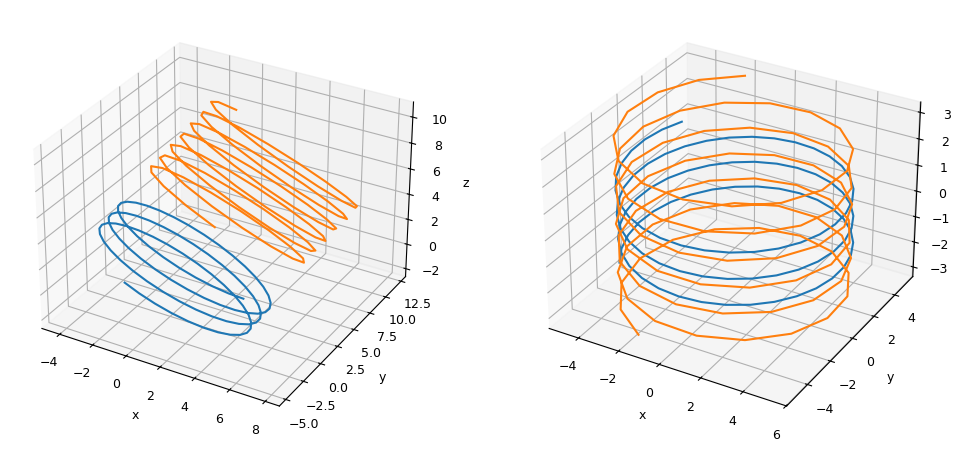

In [3]:
x1,y1,z1 =  helix(start = np.array([0.,0.,0.]), n_steps=100, radius=5, pitch=1.0, clockwise=True, step=1.0)
x2,y2,z2 =  helix(start = np.array([1.,5.,3.]), n_steps=100, radius=5, pitch=-1.0, clockwise=False, step=2.0)
fig,ax = plt.subplots(ncols= 2,subplot_kw={"projection":'3d'},figsize=(12,6))
ax[0].plot(x1,y1,z1)
ax[0].plot(x2,y2,z2)

xyz1, speed1 = canonicalize_trajectory(np.array([x1,y1,z1]).T,normalize_step=True)
#xyz2, speed = canonicalize_trajectory_1(np.array([x1,y1,z1]).T,normalize_step=True)
xyz2, speed2 = canonicalize_trajectory(np.array([x2,y2,z2]).T,normalize_step=True)

ax[1].plot(xyz1[:,0],xyz1[:,1],xyz1[:,2])
ax[1].plot(xyz2[:,0],xyz2[:,1],xyz2[:,2])
for i in range(2):
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('y')
    ax[i].set_zlabel('z')
#fig.savefig('helix_disambiguation.pdf',bbox_inches='tight')

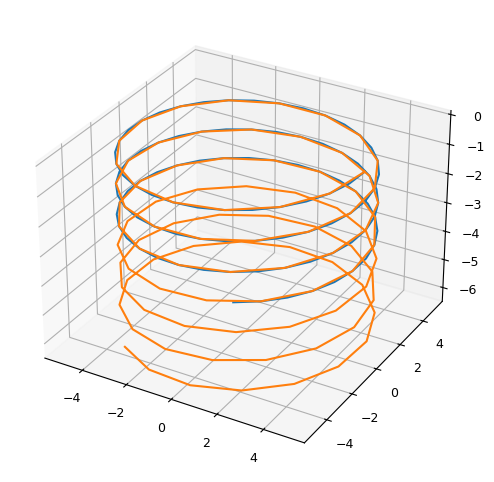

In [15]:
x1,y1,z1 =  helix(start = np.array([0.,0.,0.]), n_steps=100, radius=5, pitch=1.0, clockwise=True, step=1.0,axis=[0.,0.,1.])
x2,y2,z2 =  helix(start = np.array([0.,0.,0.]), n_steps=100, radius=5, pitch=1.0, clockwise=True, step=2.0,axis=[0.,0.,1.])

fig,ax = plt.subplots(subplot_kw={'projection':'3d'},figsize=(6,6))
ax.plot(x1,y1,z1)

ax.plot(x2,y2,z2)

In [36]:
xyz = np.array([x2,y2,z2]).T
print(xyz.shape)
# Calculate vector differences between points
diffs = xyz[1:] - xyz[:-1]

# Calculate L2 norm (distance/speed) for each segment
# Handle division by zero for duplicate points by adding epsilon if needed, 
# or rely on valid input.
distances = np.linalg.norm(diffs, axis=1)

# Normalize vectors to unit length
# Avoid division by zero: where distance is 0, vector remains 0
with np.errstate(divide='ignore', invalid='ignore'):
    unit_diffs = diffs / distances[:, None]
unit_diffs[np.isnan(unit_diffs)] = 0.0

# Reconstruct path: Start at origin (0,0...), cumsum unit steps
# We prepend a row of zeros to match original shape K
X_reconstructed = np.vstack([np.array(xyz[0]), np.cumsum(unit_diffs, axis=0)+xyz[0]])

# Store speeds and update X for the subsequent alignment
speeds = distances
X = X_reconstructed

(100, 3)


In [37]:
print(np.linalg.norm(X[1:] - X[:-1],axis=1))
xyz1 = np.array([x1,y1,z1]).T
print(np.linalg.norm(xyz1[1:]-xyz1[:-1],axis=1))
print(X[0])
print(xyz1[0])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1.]
[1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667 1.00889667
 1.00889667 1.00889667 1.00

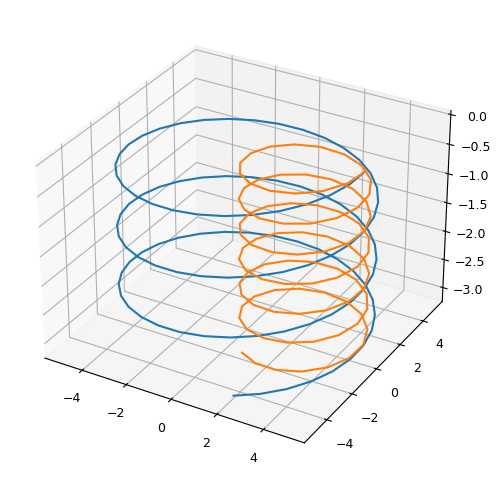

In [38]:
fig,ax = plt.subplots(subplot_kw={'projection':'3d'},figsize=(6,6))
ax.plot(x1,y1,z1)

ax.plot(X[:,0],X[:,1],X[:,2])

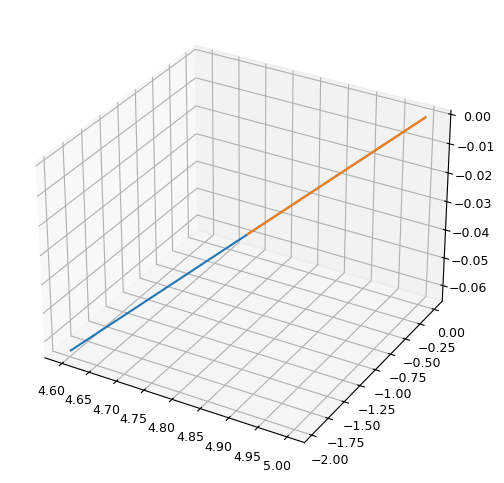

In [ ]:
fig,ax = plt.subplots(subplot_kw={'projection':'3d'},figsize=(6,6))
ax.plot(xyz[:2,0],xyz[:2,1],xyz[:2,2])
ax.plot(X[:2,0],X[:2,1],X[:2,2])

